In [130]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
import pickle as pkl

## Load solutions 

In [131]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                uncertainty_path = (
                    exp_folder
                    / "uncertainty_annotation"
                    / "candidates_with_uncertainties.csv"
                )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():

                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [132]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [133]:
path_to_results_post_loop3 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_loop3")
paths_post_loop3 = os.listdir(path_to_results_post_loop3)

In [134]:
cell_types = ["CD14Mono",
              "CD16Mono", 
              "preProB", 
              "ProB"]

In [135]:
raw_solutions_post_loop3 = load_pure_cell_type_solutions(
    path_to_results_post_loop3,
    paths_post_loop3,
    cell_types,
)

100%|██████████| 6/6 [01:42<00:00, 17.09s/it]


In [136]:
# Concatenate data frame 
raw_solutions_post_loop3 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_post_loop3.items()
}

In [137]:
for col in raw_solutions_post_loop3["CD14Mono"].columns:
    print(col)

Unnamed: 0
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
il7_[ng_ml]
mcsf_[ng_ml]
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
il7_[ng_ml]:rescaled
mcsf_[ng_ml]:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation

### Initialize targets

Only 4 types were optimized 

In [138]:
annotation_cfg

{'protocol_columns': ['gm-csf_[ng_ml]',
  'tpo_[ng_ml]',
  'sr1_[nm]',
  'um171_[nm]',
  'um729_[µm]',
  'scf_[ng_ml]',
  'butyzamide_[nm]',
  'retinoic_acid_[µm]',
  'ldl_[ng_ml]',
  'il3_[ng_ml]',
  'o2_[%]',
  'days_of_culture',
  'il7_[ng_ml]',
  'mcsf_[ng_ml]'],
 'protocol_obs_key_added': 'protocol_id',
 'protocol_sep': '_',
 'one_hot_uns_key_added': 'one_hot',
 'protocol_obsm_key': 'condition_concat',
 'scatter_columns': ['FSC-A :: FSC - Area',
  'FSC-H :: FSC - Height',
  'FSC-W :: FSC - Width',
  'SSC-A :: SSC - Area',
  'SSC-H :: SSC - Height',
  'SSC-W :: SSC - Width'],
 'base_sample_rep': None,
 'scatter_obsm_key': 'X_scatter',
 'concat_obsm_key': 'X_concat',
 'log1p_exp_cols': ['gm-csf_[ng_ml]',
  'tpo_[ng_ml]',
  'sr1_[nm]',
  'um171_[nm]',
  'um729_[µm]',
  'scf_[ng_ml]',
  'butyzamide_[nm]',
  'retinoic_acid_[µm]',
  'ldl_[ng_ml]',
  'il3_[ng_ml]',
  'o2_[%]',
  'days_of_culture',
  'il7_[ng_ml]',
  'mcsf_[ng_ml]'],
 'log21p_exp_cols': []}

In [139]:
# Cell type fractions
celltype_fraction = {"CD14Mono": 0.01,
                      "CD16Mono": 0.01, 
                     "preProB": 0.01, 
                     "ProB": 0.01}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    'il7_[ng_ml]',
    'mcsf_[ng_ml]',
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
]

### Filter values

In [140]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    raw_solutions_post_loop3,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols
)

In [141]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", raw_solutions_post_loop3[ct].shape[0], "\n")

Filtered CD14Mono number of solutions: 461
Unfiltered CD14Mono number of solutions: 34650 

Filtered CD16Mono number of solutions: 2838
Unfiltered CD16Mono number of solutions: 29750 

Filtered preProB number of solutions: 2859
Unfiltered preProB number of solutions: 37250 

Filtered ProB number of solutions: 11
Unfiltered ProB number of solutions: 35950 



In [142]:
for ct in raw_solutions_post_loop3:
    print(raw_solutions_post_loop3[ct][f"{ct}_prop"].argmax())

23935
14277
35483
35710


/tmp/ipykernel_340159/3913199637.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


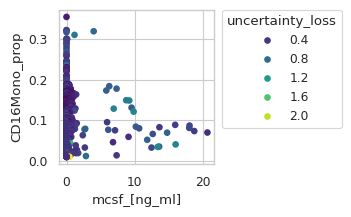

In [183]:
plt.figure(figsize=(2, 2))

ax = sns.scatterplot(
    data=filtered_df["CD16Mono"],
    x="mcsf_[ng_ml]",
    y="CD16Mono_prop",
    hue="uncertainty_loss",
    palette="viridis",
    edgecolor="none",
)

ax.legend(
    title="uncertainty_loss",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_340159/3437156067.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


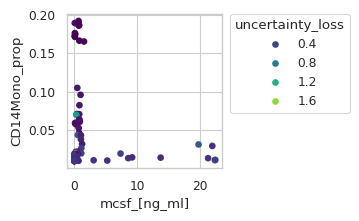

In [189]:
plt.figure(figsize=(2, 2))

ax = sns.scatterplot(
    data=filtered_df["CD14Mono"],
    x="mcsf_[ng_ml]",
    y="CD14Mono_prop",
    hue="uncertainty_loss",
    palette="viridis",
    edgecolor="none",
)

ax.legend(
    title="uncertainty_loss",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_340159/2646127100.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


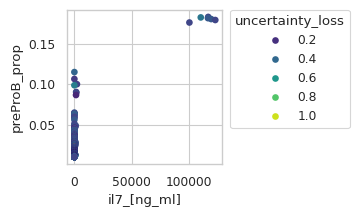

In [203]:
plt.figure(figsize=(2, 2))

ax = sns.scatterplot(
    data=annotated_df["preProB"],
    x="il7_[ng_ml]",
    y="preProB_prop",
    hue="uncertainty_loss",
    palette="viridis",
    edgecolor="none",
)

ax.legend(
    title="uncertainty_loss",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_340159/593782773.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


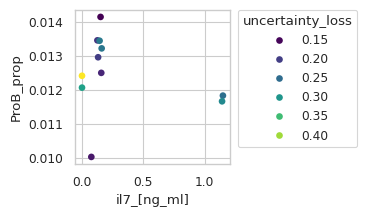

In [200]:
plt.figure(figsize=(2, 2))

ax = sns.scatterplot(
    data=filtered_df["ProB"],
    x="il7_[ng_ml]",
    y="ProB_prop",
    hue="uncertainty_loss",
    palette="viridis",
    edgecolor="none",
)

ax.legend(
    title="uncertainty_loss",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

### Filter values

In [193]:
for cell_type in filtered_df:
    # Clean filtered data frames 
    filtered_df[cell_type]= filtered_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)

    # Clean unfiltered dataframes 
    annotated_df[cell_type]= annotated_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)

In [194]:
for cell_type in filtered_df:
    print(filtered_df[cell_type].shape)

(461, 21)
(2838, 21)
(2859, 21)
(11, 21)


In [195]:
filtered_df_subsample = {}

for cell_type in filtered_df:
    if filtered_df[cell_type].shape[0] > 200:
        filtered_df_subsample_ct = []
        sorted_df_uncertainty = filtered_df[cell_type].sort_values(by="uncertainty_loss", ascending=True)
        filtered_df_subsample_ct.append(sorted_df_uncertainty[:100])
        filtered_df_subsample_ct.append(sorted_df_uncertainty[-100:])
        filtered_df_subsample_ct = pd.concat(filtered_df_subsample_ct, axis=0)
        filtered_df_subsample[cell_type] = filtered_df_subsample_ct
    else:
        filtered_df_subsample[cell_type] = filtered_df[cell_type]

for cell_type in filtered_df_subsample:
    print(cell_type)
    print(filtered_df_subsample[cell_type].shape)

CD14Mono
(200, 21)
CD16Mono
(200, 21)
preProB
(200, 21)
ProB
(11, 21)


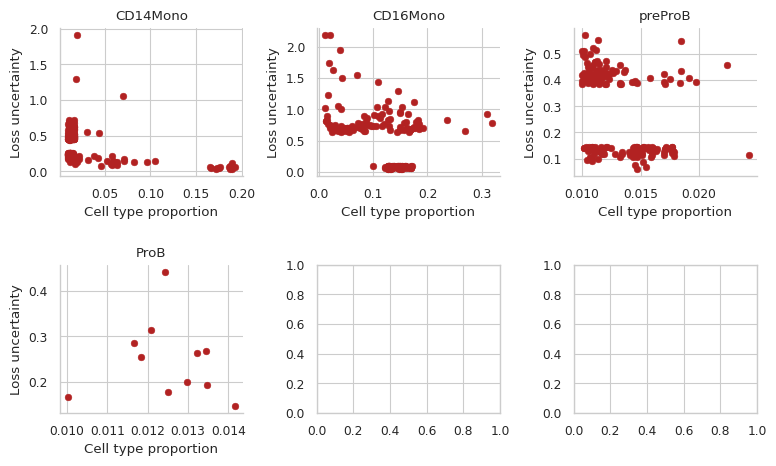

In [196]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9,5))
fig.subplots_adjust(
    hspace=0.6,   # vertical space between rows
    wspace=0.4    # horizontal space between columns
)
axes = axes.flatten()  # make indexing easy

for i, cell_type in enumerate(filtered_df_subsample):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = filtered_df_subsample[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.scatterplot(
        data=df_plot,
        x=f"{cell_type_safe}_prop",
        y="uncertainty_loss",
        ax=ax,
        edgecolor=None, 
        color="firebrick", 
    )

    # ax.set_yscale("log")   
    ax.set_title(cell_type)
    ax.set_xlabel("Cell type proportion")
    ax.set_ylabel("Loss uncertainty")
    sns.despine(ax=ax)

In [197]:
RESULT_PATH = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/results_loop3")
RESULT_PATH_FILTERED = RESULT_PATH / "filtered"
RESULT_PATH_FILTERED.mkdir(exist_ok=True, parents=True)
RESULT_PATH_ANNOTATED = RESULT_PATH / "annotated"
RESULT_PATH_ANNOTATED.mkdir(exist_ok=True, parents=True)

# Save results 
for cell_type in filtered_df_subsample:
    filtered_df_subsample[cell_type].to_csv(RESULT_PATH / "filtered" / f"filtered_candidates_{cell_type}.csv")
    annotated_df[cell_type].to_csv(RESULT_PATH / "annotated" / f"annotated_candidates_{cell_type}.csv")

with open(RESULT_PATH / "fitlered_populations.pkl", "wb") as file:
    pkl.dump(filtered_df, file)